# Convolutional Hybrid QNN — Spread Dataset (5-Class)
**Architecture:** CNN feature extractor → Classical skip branch + Quantum circuit → PQ-FiLM fusion → 5-class softmax

- Input: 16×512 spectrogram from IQ signal (FFT-based feature extraction)
- Quantum: AngleEmbedding + BasicEntanglerLayers (4 qubits, 4 layers)
- Fusion: FiLM modulation + gating (QuantumGuidedFusion)
- Labels: Spread 0.5g / 1.0g / 1.5g / 2.0g / 2.5g

In [1]:
import os
import random
import copy
import json
import time
import math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
from scipy.signal import get_window
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ==========================================
# 1. STRICT REPRODUCIBILITY SETUP
# ==========================================
SEED = 42

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device} | Seed locked to: {SEED}')

Using device: cuda | Seed locked to: 42


In [2]:
# ==========================================
# 2. DATASET CONFIGURATION
# ==========================================
BASE_DIR = Path('/home/sammarv/quantum_corrosion')

TARGET_CLASSES = [
    {'id': 0, 'name': 'Spread 0.5g', 'path_sub': 'data/raw/0.5/0.5.iq',     'gram': 0.5},
    {'id': 1, 'name': 'Spread 1.0g', 'path_sub': 'data/raw/1/1.iq',       'gram': 1.0},
    {'id': 2, 'name': 'Spread 1.5g', 'path_sub': 'data/raw/1.5/1.5.iq', 'gram': 1.5},
    {'id': 3, 'name': 'Spread 2.0g', 'path_sub': 'data/raw/2/2.iq',       'gram': 2.0},
    {'id': 4, 'name': 'Spread 2.5g', 'path_sub': 'data/raw/2.5/2.5.iq', 'gram': 2.5},
]

N_CLASSES   = len(TARGET_CLASSES)
LABEL_NAMES = [tc['name'] for tc in TARGET_CLASSES]

OUT_DIR = BASE_DIR / 'results/spread_conv_hybrid_qnn'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# FFT / spectrogram parameters (same as dual-branch notebook)
FFT_SIZE        = 4096
N_STACKS        = 16
OVERLAP         = 0.25
HOP             = int(FFT_SIZE * (1 - OVERLAP))
SAMPLES_PER_IMG = N_STACKS * HOP + (FFT_SIZE - HOP)
WIN             = get_window('hann', FFT_SIZE).astype(np.float32)

# Open all memmap files and report how many images are available
iqs = {}
for tc in TARGET_CLASSES:
    p = BASE_DIR / tc['path_sub']
    iq = np.memmap(str(p), dtype='complex64', mode='r')
    n_imgs = len(iq) // SAMPLES_PER_IMG
    iqs[tc['id']] = iq
    print(f"  label={tc['id']}  {tc['name']:14s}  images={n_imgs:,}")

print(f'\nSAMPLES_PER_IMG: {SAMPLES_PER_IMG:,}')

  label=0  Spread 0.5g     images=9,585
  label=1  Spread 1.0g     images=8,666
  label=2  Spread 1.5g     images=9,141
  label=3  Spread 2.0g     images=10,416
  label=4  Spread 2.5g     images=10,643

SAMPLES_PER_IMG: 50,176


In [3]:
# ==========================================
# 3. FEATURE EXTRACTION  (16 × 512 spectrogram)
# ==========================================

def extract_sota_features(iq_mmap, img_idx):
    """Extract a (16, 512) log-magnitude spectrogram for image img_idx."""
    start = img_idx * SAMPLES_PER_IMG
    end   = start + SAMPLES_PER_IMG
    if end > len(iq_mmap):
        return None

    frames = np.empty((N_STACKS, FFT_SIZE), dtype='complex64')
    for i in range(N_STACKS):
        s = start + i * HOP
        frames[i] = iq_mmap[s : s + FFT_SIZE]

    spec    = np.fft.fftshift(np.fft.fft(frames * WIN, axis=1), axes=1)
    mag     = np.abs(spec).astype(np.float32)
    spec_db = 20.0 * np.log10(mag + 1e-12)
    # Bin 4096 frequencies → 512 by averaging groups of 8
    spec_512 = spec_db.reshape(N_STACKS, 512, 8).mean(axis=2)  # (16, 512)
    return spec_512


def extract_class(label, n_samples, n_workers=16, desc=''):
    """Extract n_samples spectrograms for one class, with noise augmentation."""
    iq     = iqs[label]
    n_imgs = len(iq) // SAMPLES_PER_IMG
    idxs   = np.random.choice(n_imgs, size=n_samples, replace=(n_samples > n_imgs))

    features, labels_out = [], []

    def _worker(idx):
        spec = extract_sota_features(iq, int(idx))
        if spec is None:
            return None, None
        # Noise augmentation (5% std of signal)
        sig_std = spec.std()
        noise   = np.random.randn(*spec.shape).astype(np.float32) * (sig_std * 0.05)
        return spec, spec + noise  # original + augmented

    t0   = time.time()
    done = 0
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futs = {ex.submit(_worker, idx): idx for idx in idxs}
        for fut in as_completed(futs):
            orig, aug = fut.result()
            if orig is not None:
                features.append(orig)
                features.append(aug)
                labels_out.extend([label, label])
            done += 1
            if done % 500 == 0 or done == len(idxs):
                e = time.time() - t0
                print(f'  [{desc}] {done}/{len(idxs)}  {e:.0f}s')

    return features, labels_out


print('Feature extraction utilities ready.')

Feature extraction utilities ready.


In [4]:
# ==========================================
# 4. BUILD DATASET  (balanced, cached)
# ==========================================
cache_dir = OUT_DIR / 'feature_cache'
cache_dir.mkdir(exist_ok=True)

# Use only a fraction of the original planned sample count per class
DATASET_FRACTION = 0.10
SAMPLES_PER_CLASS_BASE = 3000
SAMPLES_PER_CLASS = max(1, int(SAMPLES_PER_CLASS_BASE * DATASET_FRACTION))
fraction_tag = f"{int(DATASET_FRACTION * 100)}pct"

X_cache = cache_dir / f'X_spec_{fraction_tag}.npy'
y_cache = cache_dir / f'y_{fraction_tag}.npy'

if X_cache.exists() and y_cache.exists():
    print(f'Loading {fraction_tag} features from cache...')
    X_all = np.load(X_cache)
    y_all = np.load(y_cache)
else:
    print(f'Extracting features ({SAMPLES_PER_CLASS} imgs/class from base {SAMPLES_PER_CLASS_BASE} @ {DATASET_FRACTION:.0%} × {N_CLASSES} classes × 2 aug)...')
    all_feats, all_labels = [], []
    for tc in TARGET_CLASSES:
        feats, lbls = extract_class(
            label=tc['id'],
            n_samples=SAMPLES_PER_CLASS,
            desc=tc['name']
        )
        all_feats.extend(feats)
        all_labels.extend(lbls)

    X_all = np.stack(all_feats).astype(np.float32)   # (N, 16, 512)
    y_all = np.array(all_labels, dtype=np.int64)
    np.nan_to_num(X_all, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    np.save(X_cache, X_all)
    np.save(y_cache, y_all)
    print(f'Saved {fraction_tag} cache.')

print(f'Dataset fraction: {DATASET_FRACTION:.0%}')
print(f'Dataset shape: {X_all.shape}  labels: {np.bincount(y_all)}')

Extracting features (300 imgs/class from base 3000 @ 10% × 5 classes × 2 aug)...
  [Spread 0.5g] 300/300  0s
  [Spread 1.0g] 300/300  0s
  [Spread 1.5g] 300/300  0s
  [Spread 2.0g] 300/300  0s
  [Spread 2.5g] 300/300  0s
Saved 10pct cache.
Dataset fraction: 10%
Dataset shape: (3000, 16, 512)  labels: [600 600 600 600 600]


In [5]:
# ==========================================
# 5. PREPROCESSING & TRAIN/TEST SPLIT
# ==========================================

# StandardScaler on flattened features, then reshape back
N, H, W = X_all.shape
X_flat   = X_all.reshape(N, -1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(N, H, W).astype(np.float32)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print(f'Train: {X_train_np.shape}  Test: {X_test_np.shape}')
print(f'Train class counts: {np.bincount(y_train_np)}')
print(f'Test  class counts: {np.bincount(y_test_np)}')

# Reshape to (N, 1, 16, 512) for Conv2d
X_train_t = torch.tensor(X_train_np[:, None, :, :], dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.long)
X_test_t  = torch.tensor(X_test_np[:, None, :, :], dtype=torch.float32)
y_test_t  = torch.tensor(y_test_np, dtype=torch.long)

batch_size = 32
_n_workers = min(4, os.cpu_count() or 1)
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=_n_workers,
    pin_memory=True,
    persistent_workers=True,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False,
    num_workers=_n_workers,
    pin_memory=True,
    persistent_workers=True,
)

print(f'\nbatch_size={batch_size}  train_batches={len(train_loader)}  test_batches={len(test_loader)}')

Train: (2400, 16, 512)  Test: (600, 16, 512)
Train class counts: [480 480 480 480 480]
Test  class counts: [120 120 120 120 120]

batch_size=32  train_batches=75  test_batches=19


In [6]:
# ==========================================
# 6. QUANTUM NODE  (Q-NAS optimal: 4 qubits, 4 layers, BasicEntangling)
# ==========================================
n_qubits = 4
n_layers = 4

def _make_quantum_device(n_q):
    try:
        dev = qml.device('lightning.gpu', wires=n_q)
        print(f'Quantum device: {dev.name}')
        return dev, 'adjoint'
    except Exception:
        pass
    # Skip lightning.qubit: for batched 4-qubit simulation, default.qubit+backprop
    # is ~5x faster (no batch broadcasting in lightning.qubit's adjoint path).
    dev = qml.device('default.qubit', wires=n_q)
    print(f'Quantum device: {dev.name}')
    return dev, 'backprop'

dev, diff_method = _make_quantum_device(n_qubits)

# BasicEntangling weight shape: (n_layers, n_qubits)
weight_shapes = {'weights': (n_layers, n_qubits)}

@qml.qnode(dev, interface='torch', diff_method=diff_method)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class BatchedQuantumLayer(nn.Module):
    """Drop-in for qml.qnn.TorchLayer that avoids its per-sample sequential loop.

    TorchLayer.forward() calls qnode once per sample via torch.unbind.
    Calling qnode directly with (B, n_qubits) triggers default.qubit batch
    broadcasting — all samples processed in one vectorized pass (~8x faster).
    Batched output shape is (n_qubits * B,) interleaved by qubit, so we
    reshape with .view(n_qubits, B).t() to recover (B, n_qubits).
    """
    def __init__(self, n_l, n_q, q_node):
        super().__init__()
        self.n_qubits = n_q
        self.qnode = q_node
        self.weights = nn.Parameter(
            torch.empty(n_l, n_q).uniform_(-np.pi, np.pi)
        )

    def forward(self, x):
        # x: (B, n_qubits)
        B = x.shape[0]
        out = self.qnode(x, self.weights)  # (n_qubits * B,) interleaved by qubit
        return out.float().view(self.n_qubits, B).t().contiguous()  # (B, n_qubits)

Quantum device: Default qubit PennyLane plugin


In [7]:
# ==========================================
# 7. MODEL ARCHITECTURE
# ==========================================

class QuantumGuidedFusion(nn.Module):
    """FiLM modulation of classical features conditioned on quantum output."""
    def __init__(self, c_dim=64, q_dim=4, n_classes=4):
        super().__init__()
        self.film_net = nn.Sequential(
            nn.Linear(q_dim, 32),
            nn.GELU(),
            nn.Linear(32, c_dim * 2)
        )
        self.gate = nn.Sequential(
            nn.Linear(c_dim + q_dim, c_dim),
            nn.Sigmoid()
        )
        self.classifier = nn.Linear(c_dim, n_classes)

    def forward(self, c, q):
        film_params       = self.film_net(q)
        gamma, beta       = torch.chunk(film_params, 2, dim=1)
        c_mod             = c * (gamma + 1.0) + beta
        gate_val          = self.gate(torch.cat([c_mod, q], dim=1))
        fused_features    = gate_val * c_mod + (1 - gate_val) * c
        return self.classifier(fused_features)


class ConvolutionalHybridQNN(nn.Module):
    """
    Input : (B, 1, 16, 512)  — normalised log-magnitude spectrogram
    Output: (B, N_CLASSES)   — 5-class logits (Spread 0.5g / 1.0g / 1.5g / 2.0g / 2.5g)
    """
    def __init__(self, n_cls=N_CLASSES, dropout_cnn=0.2350, dropout_skip=0.2012):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),          # → (16, 8, 256)
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),          # → (32, 4, 128)
            nn.Flatten(),
            nn.Linear(32 * 4 * 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_cnn)
        )
        self.qnn_proj = nn.Sequential(
            nn.Linear(256, n_qubits),
            nn.Sigmoid()
        )
        self.qnn = BatchedQuantumLayer(n_layers, n_qubits, qnode)

        self.classical_skip = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_skip),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_skip)
        )
        self.fusion_module = QuantumGuidedFusion(c_dim=64, q_dim=n_qubits, n_classes=n_cls)

    def forward(self, x):
        features  = self.cnn(x)
        qbn_input = self.qnn_proj(features) * (2.0 * np.pi)
        q_feats   = self.qnn(qbn_input)
        c_feats   = self.classical_skip(features)
        return self.fusion_module(c_feats, q_feats)


model = ConvolutionalHybridQNN().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

# Smoke test
with torch.no_grad():
    _x = X_train_t[:2].to(device)
    _out = model(_x)
    print(f'Forward OK — output shape: {_out.shape}  (expect [2, {N_CLASSES}])')

Trainable params: 4,251,289
Forward OK — output shape: torch.Size([2, 5])  (expect [2, 5])


In [8]:
# ==========================================
# 8. TRAINING LOOP
# ==========================================
epochs  = 100
patience = 12

# Inverse-frequency class weights
class_counts = np.bincount(y_train_np)
cw_vals      = 1.0 / class_counts.astype(np.float32)
cw_vals      = cw_vals / cw_vals.sum() * N_CLASSES
loss_weights = torch.tensor(cw_vals, dtype=torch.float32).to(device)
print('Class weights:', [f'{w:.4f}' for w in cw_vals.tolist()])

# Optimal hyper-parameters (from Optuna Phase 1 on dual-branch)
lr           = 0.00079146
weight_decay = 1.11589e-06

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(weight=loss_weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=6)

print('\n' + '='*65)
print('STARTING TRAINING — Convolutional Hybrid QNN (Spread 5-class)')
print('='*65)

best_f1         = 0.0
best_loss       = float('inf')
epochs_no_impr  = 0
best_weights    = None
history         = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(epochs):
    # ── train ──────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs  = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        out  = model(inputs)
        loss = criterion(out, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # ── validate ───────────────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    all_preds, all_tgts = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs  = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            out  = model(inputs)
            loss = criterion(out, targets)
            running_val_loss += loss.item() * inputs.size(0)
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_tgts.extend(targets.cpu().numpy())
    val_loss = running_val_loss / len(test_loader.dataset)

    acc    = accuracy_score(all_tgts, all_preds)
    val_f1 = f1_score(all_tgts, all_preds, average='macro', zero_division=0)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {acc:.4f} | Val F1: {val_f1:.4f}')

    if val_f1 > best_f1:
        best_f1      = val_f1
        best_loss    = val_loss
        epochs_no_impr = 0
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, OUT_DIR / 'conv_hybrid_qnn_best.pt')
    else:
        epochs_no_impr += 1

    if epochs_no_impr >= patience:
        print(f'\nEarly Stopping triggered at epoch {epoch+1}.')
        break

print(f'\nBest Val F1: {best_f1:.4f}')

Class weights: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']

STARTING TRAINING — Convolutional Hybrid QNN (Spread 5-class)
Epoch 001 | Train Loss: 0.8045 | Val Loss: 0.3259 | Val Acc: 0.8983 | Val F1: 0.8982
Epoch 002 | Train Loss: 0.1048 | Val Loss: 0.2401 | Val Acc: 0.9250 | Val F1: 0.9243
Epoch 003 | Train Loss: 0.0439 | Val Loss: 0.1339 | Val Acc: 0.9517 | Val F1: 0.9517
Epoch 004 | Train Loss: 0.0185 | Val Loss: 0.1381 | Val Acc: 0.9567 | Val F1: 0.9566
Epoch 005 | Train Loss: 0.0249 | Val Loss: 0.2282 | Val Acc: 0.9417 | Val F1: 0.9416
Epoch 006 | Train Loss: 0.0101 | Val Loss: 0.2766 | Val Acc: 0.9467 | Val F1: 0.9466
Epoch 007 | Train Loss: 0.0124 | Val Loss: 0.2307 | Val Acc: 0.9450 | Val F1: 0.9450
Epoch 008 | Train Loss: 0.0124 | Val Loss: 0.2796 | Val Acc: 0.9467 | Val F1: 0.9467
Epoch 009 | Train Loss: 0.0198 | Val Loss: 0.3048 | Val Acc: 0.9300 | Val F1: 0.9304
Epoch 010 | Train Loss: 0.0388 | Val Loss: 0.2316 | Val Acc: 0.9483 | Val F1: 0.9482
Epoch 011 | Train Los

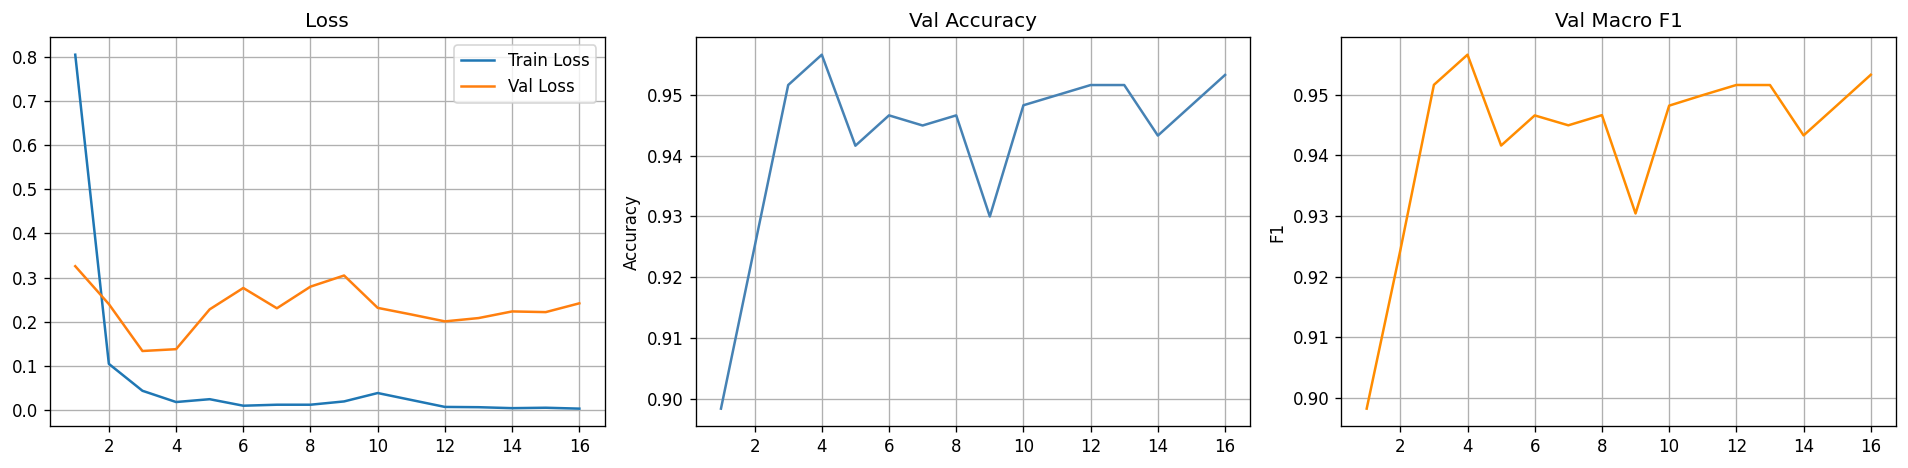

In [9]:
# ==========================================
# 9. TRAINING CURVES
# ==========================================
ep_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(ep_range, history['train_loss'], label='Train Loss')
axes[0].plot(ep_range, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep_range, history['val_acc'], color='steelblue')
axes[1].set_title('Val Accuracy'); axes[1].set_ylabel('Accuracy'); axes[1].grid(True)

axes[2].plot(ep_range, history['val_f1'], color='darkorange')
axes[2].set_title('Val Macro F1'); axes[2].set_ylabel('F1'); axes[2].grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=200)
plt.show()

In [10]:
# ==========================================
# 10. FINAL EVALUATION  (best checkpoint)
# ==========================================
model.load_state_dict(best_weights)
model.eval()

final_preds, final_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs  = inputs.to(device)
        out     = model(inputs)
        preds   = torch.argmax(out, dim=1).cpu().numpy()
        final_preds.extend(preds)
        final_targets.extend(targets.numpy())

final_preds   = np.array(final_preds)
final_targets = np.array(final_targets)

final_acc        = accuracy_score(final_targets, final_preds)
final_f1_macro   = f1_score(final_targets, final_preds, average='macro')
final_f1_weighted = f1_score(final_targets, final_preds, average='weighted')

print('=' * 65)
print('FINAL HYBRID QNN EVALUATION — TEST SET  (Spread 5-class)')
print('=' * 65)
print(f'Overall Accuracy   : {final_acc:.4f}')
print(f'Macro F1-Score     : {final_f1_macro:.4f}')
print(f'Weighted F1-Score  : {final_f1_weighted:.4f}')
print('\n--- CLASSIFICATION REPORT ---')
print(classification_report(final_targets, final_preds,
                             target_names=LABEL_NAMES, digits=4))

FINAL HYBRID QNN EVALUATION — TEST SET  (Spread 5-class)
Overall Accuracy   : 0.9567
Macro F1-Score     : 0.9566
Weighted F1-Score  : 0.9566

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

 Spread 0.5g     0.9048    0.9500    0.9268       120
 Spread 1.0g     0.9516    0.9833    0.9672       120
 Spread 1.5g     0.9828    0.9500    0.9661       120
 Spread 2.0g     1.0000    1.0000    1.0000       120
 Spread 2.5g     0.9474    0.9000    0.9231       120

    accuracy                         0.9567       600
   macro avg     0.9573    0.9567    0.9566       600
weighted avg     0.9573    0.9567    0.9566       600



Saved → /home/sammarv/quantum_corrosion/results/spread_conv_hybrid_qnn/confusion_matrix.png


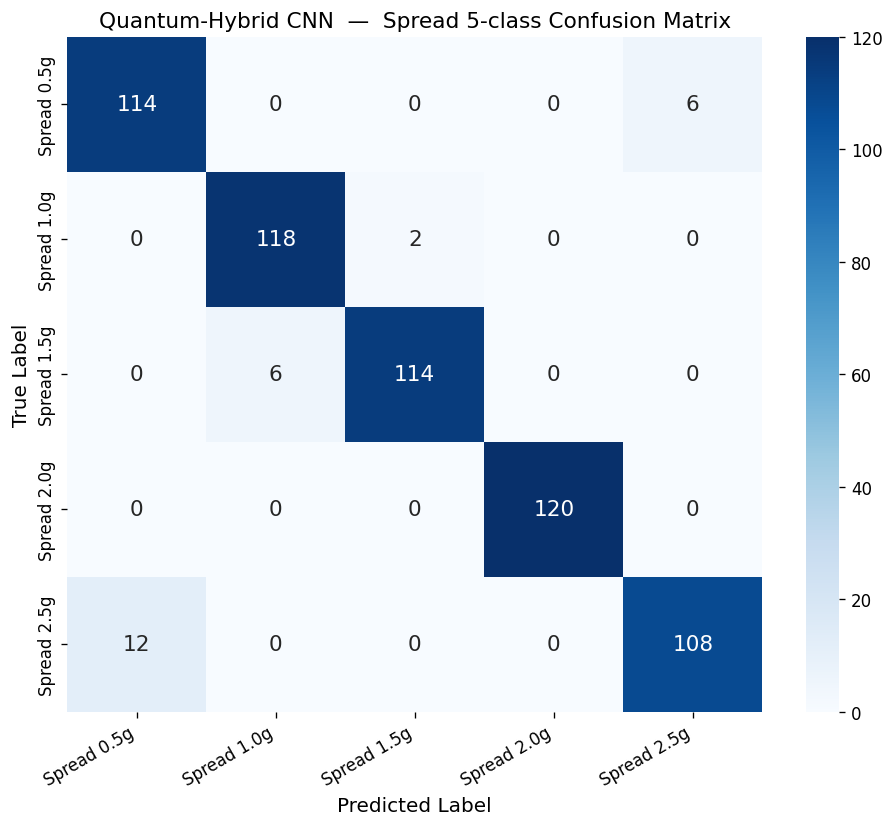

In [11]:
# ==========================================
# 11. CONFUSION MATRIX
# ==========================================
try:
    import seaborn as sns
    cm = confusion_matrix(final_targets, final_preds)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                annot_kws={'size': 13}, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_title('Quantum-Hybrid CNN  —  Spread 5-class Confusion Matrix', fontsize=13)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=300)
    print(f'Saved → {OUT_DIR}/confusion_matrix.png')
    plt.show()
except ImportError:
    cm = confusion_matrix(final_targets, final_preds)
    print('Confusion matrix (rows=true, cols=pred):')
    print(cm)

In [12]:
# ==========================================
# 12. SAVE SUMMARY
# ==========================================
summary = {
    'model': 'ConvolutionalHybridQNN',
    'dataset': 'Spread 5-class (0.5g / 1.0g / 1.5g / 2.0g / 2.5g)',
    'architecture': {
        'n_qubits': n_qubits,
        'n_layers': n_layers,
        'ansatz': 'BasicEntanglerLayers',
        'angle_scaling': '2*pi',
        'fusion': 'QuantumGuidedFusion (FiLM + gate)',
    },
    'hyperparams': {
        'lr': lr,
        'weight_decay': weight_decay,
        'batch_size': batch_size,
        'epochs_patience': patience,
    },
    'results': {
        'accuracy':   float(final_acc),
        'f1_macro':   float(final_f1_macro),
        'f1_weighted': float(final_f1_weighted),
        'best_val_f1': float(best_f1),
    },
    'classes': LABEL_NAMES,
}

with open(OUT_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Checkpoint : {OUT_DIR}/conv_hybrid_qnn_best.pt')
print(f'Summary    : {OUT_DIR}/results_summary.json')
print('\nModel Evaluation Complete. All results deterministic based on Seed 42.')

Checkpoint : /home/sammarv/quantum_corrosion/results/spread_conv_hybrid_qnn/conv_hybrid_qnn_best.pt
Summary    : /home/sammarv/quantum_corrosion/results/spread_conv_hybrid_qnn/results_summary.json

Model Evaluation Complete. All results deterministic based on Seed 42.


In [13]:
# 13. 10% DATASET RUN SUMMARY (added cell)
tenpct_results = {
    'dataset_fraction': float(DATASET_FRACTION),
    'samples_per_class_base': int(SAMPLES_PER_CLASS_BASE),
    'samples_per_class_used': int(SAMPLES_PER_CLASS),
    'total_samples': int(len(y_all)),
    'test_samples': int(len(final_targets)),
    'best_val_f1': float(best_f1),
    'test_accuracy': float(final_acc),
    'test_f1_macro': float(final_f1_macro),
    'test_f1_weighted': float(final_f1_weighted),
}

print('=' * 70)
print('10% DATASET EXPERIMENT RESULTS')
print('=' * 70)
for k, v in tenpct_results.items():
    if isinstance(v, float):
        print(f'{k:>24s}: {v:.4f}')
    else:
        print(f'{k:>24s}: {v}')

with open(OUT_DIR / 'results_summary_10pct.json', 'w') as f:
    json.dump(tenpct_results, f, indent=2)

print(f"\nSaved: {OUT_DIR / 'results_summary_10pct.json'}")

10% DATASET EXPERIMENT RESULTS
        dataset_fraction: 0.1000
  samples_per_class_base: 3000
  samples_per_class_used: 300
           total_samples: 3000
            test_samples: 600
             best_val_f1: 0.9566
           test_accuracy: 0.9567
           test_f1_macro: 0.9566
        test_f1_weighted: 0.9566

Saved: /home/sammarv/quantum_corrosion/results/spread_conv_hybrid_qnn/results_summary_10pct.json
